In [2]:
import matplotlib.pyplot as plt
from astropy.table import Table
import catalogue_analysis as ca
import numpy as np

In [3]:
# Read the tables whose data we are going to replot

LFN20=Table.read('sdata/LFN20Feb.fits')
LFS20=Table.read('sdata/LFS20Feb.fits')

LFN20=Table.read('sdata/LFNr_vmax_26Mar.fits')
LFS20=Table.read('sdata/LFSr_vmax_26Mar.fits')



LFNSB20=Table.read('sdata/LFNSB20Feb.fits')
LFSSB20=Table.read('sdata/LFSSB20Feb.fits')


LFNSBd20=Table.read('sdata/LFNSBd20Feb.fits')
LFSSBd20=Table.read('sdata/LFSSBd20Feb.fits')


LFN21=Table.read('sdata/LFN21Feb.fits')
LFS21=Table.read('sdata/LF21Feb.fits')
#



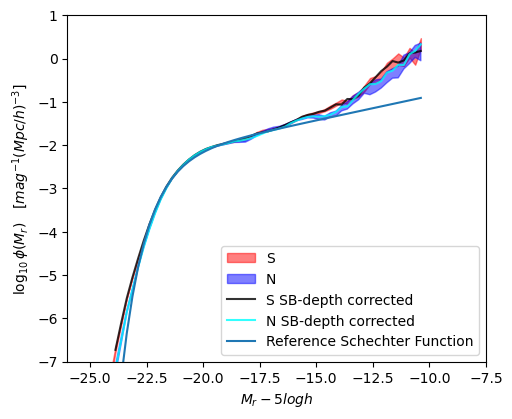

In [5]:
plt.figure(figsize=(5.4, 4.5))


#Replot the data

plt.fill_between(LFS20['mag'],LFS20['logphi_low'],LFS20['logphi_hi'], color='red',alpha=0.5,label='S')
plt.fill_between(LFN20['mag'],LFN20['logphi_low'],LFN20['logphi_hi'], color='blue',alpha=0.5,label='N')



plt.plot(LFSSBd20['mag'],LFS21['logphi'], color='black',alpha=0.8,label='S SB-depth corrected ')
plt.plot(LFNSBd20['mag'],LFN21['logphi'], color='cyan',alpha=0.8,label='N SB-depth corrected')
    

#plt.fill_between(LFS21['mag'],LFS21['logphi_low'],LFS21['logphi_hi'], color='magenta',alpha=0.8,label='S Zhelio')
#plt.fill_between(LFN21['mag'],LFN21['logphi_low'],LFN21['logphi_hi'], color='cyan',alpha=0.8,label='N Zhelio')
    
# Reference Schechter function from Sam's draft paper Table 1
Fid=ca.fiducial('r')
phi_star=Fid["phi_star"]
alpha=Fid["alpha"]
mstar=Fid["mstar"]
bin_cen=LFN20['mag']
l_lstar= 10.0**(0.4*(-bin_cen+mstar))
phi_sch= phi_star * l_lstar**(1.0+alpha) * np.exp(-l_lstar) *(np.log(10.0)/2.5)
log_phi_sch = np.log10(phi_sch)
            
plt.plot(bin_cen,log_phi_sch, label='Reference Schechter Function')
plt.xlabel('$M_r - 5 log h$')
plt.ylabel('$\log_{10} \phi(M_r)\quad  [mag^{-1} (Mpc/h)^{-3}]$')
plt.xlim([-26,-7.5])
plt.ylim([-7,1.0])
plt.legend(loc='lower right')
plt.savefig('LFSBd.pdf')
plt.show()
    
